In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Extracting Data

In [15]:
data_path = "/content/drive/MyDrive/Micro_Organism"

In [16]:
import os
files = os.listdir(data_path)
print(files)

['Paramecium', 'Hydra', 'Yeast', 'Rod_bacteria', 'Spherical_bacteria', 'Spiral_bacteria', 'Amoeba', 'Euglena']


In [17]:
import os
import shutil
from sklearn.model_selection import train_test_split

def split_dataset(src_root, dst_root, val_size=0.15, seed=41234):
    for class_name in os.listdir(src_root):
        class_dir = os.path.join(src_root, class_name)
        if not os.path.isdir(class_dir):
            continue

        images = [f for f in os.listdir(class_dir) if
                  f.lower().endswith(('.png','.jpg','.jpeg'))]

        train, val = train_test_split(images, test_size=val_size,
                                           random_state=seed)
        val_ratio = val_size / (1 - val_size)
        train, val = train_test_split(train, test_size=val_size,
                                      random_state=seed)

        for split, files in [('train', train), ('val', val)]:
            split_dir = os.path.join(dst_root, split, class_name)
            os.makedirs(split_dir, exist_ok=True)
            for f in files:
                shutil.copy(os.path.join(class_dir, f),
                            os.path.join(split_dir, f))

split_dataset(data_path, "/content/drive/MyDrive/Micro_Organism_Split")

# Transforming the Data

In [18]:
data_path = "/content/drive/MyDrive/Micro_Organism_Split"
train_path = os.path.join(data_path, "train")
val_path = os.path.join(data_path, "val")

In [19]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
# Variables
IMG_SIZE = 224
BATCH = 32

# train dataset transformation
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
])
# validation dataset transformation
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(train_path, transform=train_tf)
val_ds   = datasets.ImageFolder(val_path,   transform=val_tf)

# For class imbalance in the dataset
# Each sample gets a weight = 1 / count_of_its_class
class_counts = np.bincount(train_ds.targets)
weights = 1.0 / class_counts[train_ds.targets]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

In [20]:
train_ds = datasets.ImageFolder(train_path, transform=train_tf)
val_ds   = datasets.ImageFolder(val_path,   transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2)

print(train_ds.class_to_idx)

{'Amoeba': 0, 'Euglena': 1, 'Hydra': 2, 'Paramecium': 3, 'Rod_bacteria': 4, 'Spherical_bacteria': 5, 'Spiral_bacteria': 6, 'Yeast': 7}


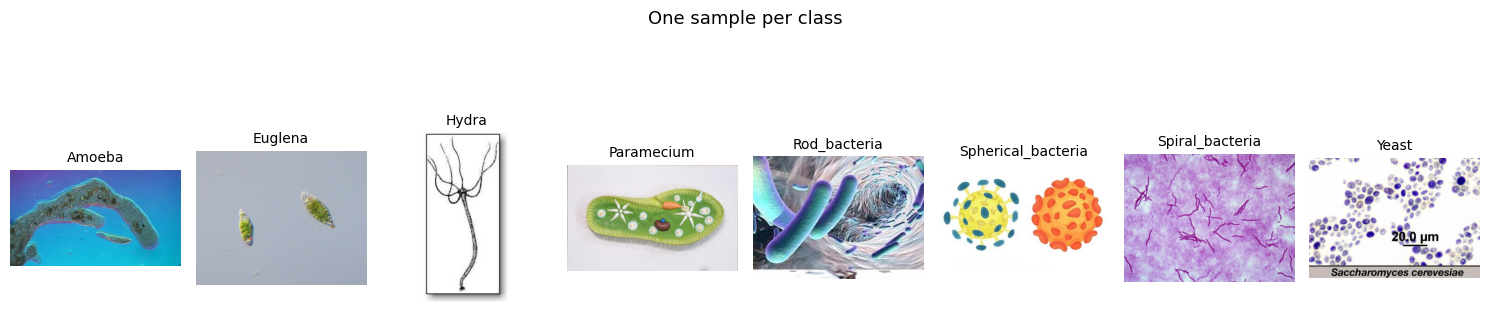

In [29]:
import matplotlib.pyplot as plt
import os
from PIL import Image

class_names = sorted(os.listdir(train_path))

fig, axes = plt.subplots(1, len(class_names), figsize=(15, 4))

for ax, class_name in zip(axes, class_names):
    class_dir = os.path.join(train_path, class_name)
    img_file  = os.listdir(class_dir)[0]          # grab the first image
    img       = Image.open(os.path.join(class_dir, img_file)).convert('RGB')

    ax.imshow(img)
    ax.set_title(class_name, fontsize=10)
    ax.axis('off')

plt.suptitle('One sample per class', fontsize=13)
plt.tight_layout()
plt.show()

# Loading the Data

## CNN

In [24]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            self._block(3,   32),   # 224 → 112
            self._block(32,  64),   # 112 → 56
            self._block(64,  128),  # 56  → 28
            self._block(128, 256),  # 28  → 14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # → (B, 256, 1, 1)
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = CNN(num_classes=len(train_ds.classes))

In [25]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS = 30
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN(num_classes=len(train_ds.classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)


history = {'epoch': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    print(f"Epoch {epoch}: Training...")
    correct, total, total_loss = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    #vVal
    print(f"Epoch {epoch}: Validation...")
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    scheduler.step()
    print(f"Epoch {epoch} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}")
    if epoch % 10 == 0:
        history['epoch'].append(epoch)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

Epoch 1: Training...
Epoch 1: Validation...
Epoch 1 | train acc: 0.2025 | val acc: 0.0962
Epoch 2: Training...
Epoch 2: Validation...
Epoch 2 | train acc: 0.2167 | val acc: 0.2788
Epoch 3: Training...
Epoch 3: Validation...
Epoch 3 | train acc: 0.2238 | val acc: 0.2212
Epoch 4: Training...
Epoch 4: Validation...
Epoch 4 | train acc: 0.2647 | val acc: 0.3365
Epoch 5: Training...
Epoch 5: Validation...
Epoch 5 | train acc: 0.2735 | val acc: 0.2885
Epoch 6: Training...
Epoch 6: Validation...
Epoch 6 | train acc: 0.2718 | val acc: 0.3077
Epoch 7: Training...
Epoch 7: Validation...
Epoch 7 | train acc: 0.2487 | val acc: 0.3365
Epoch 8: Training...
Epoch 8: Validation...
Epoch 8 | train acc: 0.3108 | val acc: 0.3173
Epoch 9: Training...
Epoch 9: Validation...
Epoch 9 | train acc: 0.2966 | val acc: 0.3077
Epoch 10: Training...
Epoch 10: Validation...
Epoch 10 | train acc: 0.2700 | val acc: 0.3269
Epoch 11: Training...
Epoch 11: Validation...
Epoch 11 | train acc: 0.3197 | val acc: 0.2981
Epoc

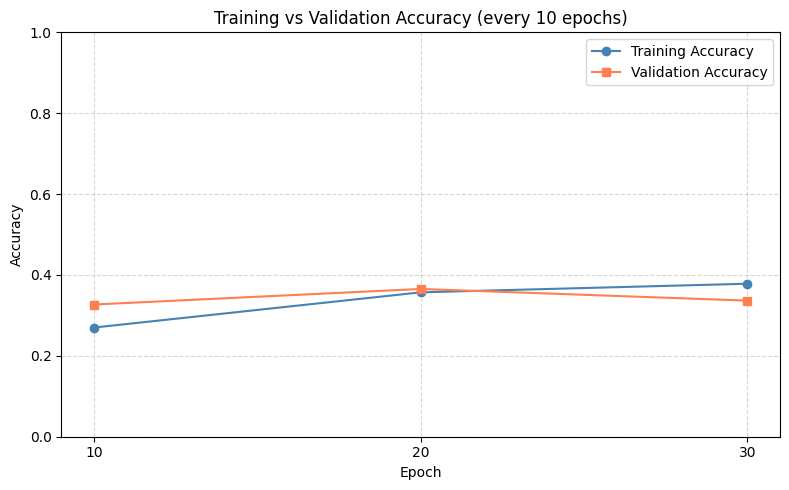

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['train_acc'], marker='o',
         label='Training Accuracy', color='steelblue')
plt.plot(history['epoch'], history['val_acc'],   marker='s',
         label='Validation Accuracy', color='coral')

plt.title('Training vs Validation Accuracy (every 10 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(history['epoch'])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

## CNN with Regularizer

In [ ]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.features = nn.Sequential(
            self._block(3,   32),   # 224 → 112
            self._block(32,  64),   # 112 → 56
            self._block(64,  128),  # 56  → 28
            self._block(128, 256),  # 28  → 14
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # → (B, 256, 1, 1)
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = CNN(num_classes=len(train_ds.classes))

In [ ]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR

EPOCHS = 30
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN(num_classes=len(train_ds.classes)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)


history = {'epoch': [], 'train_acc': [], 'val_acc': []}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):

    # Train
    model.train()
    correct, total, total_loss = 0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_acc = correct / total
    #vVal
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out = model(imgs)
            val_correct += (out.argmax(1) == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total

    scheduler.step()
    if epoch % 10 == 0:
        history['epoch'].append(epoch)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        print(f"Epoch {epoch:2d} | train acc: {train_acc:.4f} | val acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')

Epoch 10 | train acc: 0.3321 | val acc: 0.2596
Epoch 20 | train acc: 0.3499 | val acc: 0.4135
Epoch 30 | train acc: 0.4156 | val acc: 0.3942


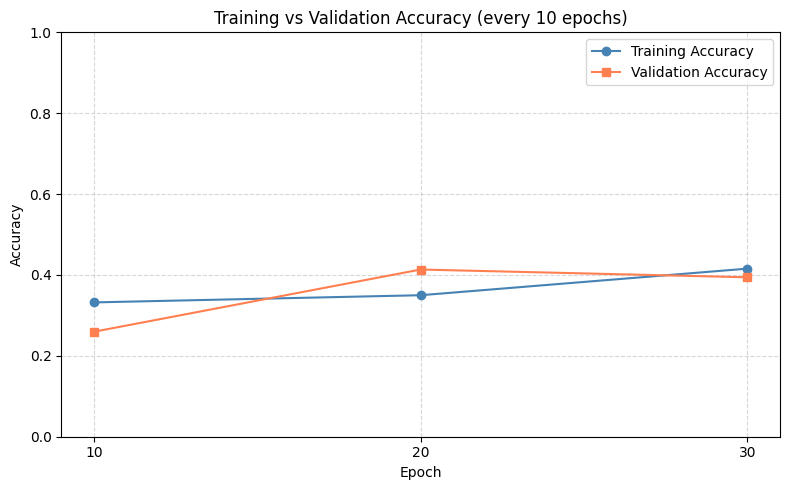

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history['epoch'], history['train_acc'], marker='o',
         label='Training Accuracy', color='steelblue')
plt.plot(history['epoch'], history['val_acc'],   marker='s',
         label='Validation Accuracy', color='coral')

plt.title('Training vs Validation Accuracy (every 10 epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(history['epoch'])
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('accuracy_plot.png', dpi=150)
plt.show()